# 02 — QC, clustering, and recreating Figure 1

Loads the AnnData built in `01_build_anndata.ipynb`, runs standard scRNA-seq QC and clustering, and reproduces the core result of Kinker et al. Figure 1: an embedding of all profiled cells that separates cleanly by **cell line of origin** rather than by cancer type — the paper's evidence that cell-line identity dominates the transcriptome, which is exactly why the downstream KSQ analysis (notebook 03) has to be interpreted per cell line / per cancer type rather than by pooling everything together.

In [1]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.set_figure_params(dpi=150, frameon=False)

DATA_DIR = os.path.join(os.getcwd(), 'data')
OUTS_DIR = os.path.join(os.getcwd(), 'outs')
FIG_DIR = os.path.join(OUTS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

adata = sc.read_h5ad(os.path.join(OUTS_DIR, '01_kinker_raw.h5ad'))
adata

AnnData object with n_obs × n_vars = 53513 × 23081
    obs: 'CellLine', 'Pool', 'Indication', 'Genes_expressed', 'Discrete_cluster_minpts5_eps1.8', 'Discrete_cluster_minpts5_eps1.5', 'Discrete_cluster_minpts5_eps1.2', 'CNA_subclone', 'SkinPig_score', 'EMTI_score', 'EMTII_score', 'EMTIII_score', 'IFNResp_score', 'p53Sen_score', 'EpiSen_score', 'StressResp_score', 'ProtMatu_score', 'ProtDegra_score', 'G1_S_score', 'G2_M_score', 'n_genes'
    var: 'n_cells'

## QC

This matrix is already a curated subset — Kinker et al. only released cells that passed their own QC and doublet-exclusion pipeline (cell line assignment agreement between expression and SNP profiles, minimum 50 cells per line). We still look at the standard per-cell metrics to confirm there's nothing pathological left, but we don't expect to need aggressive additional filtering.

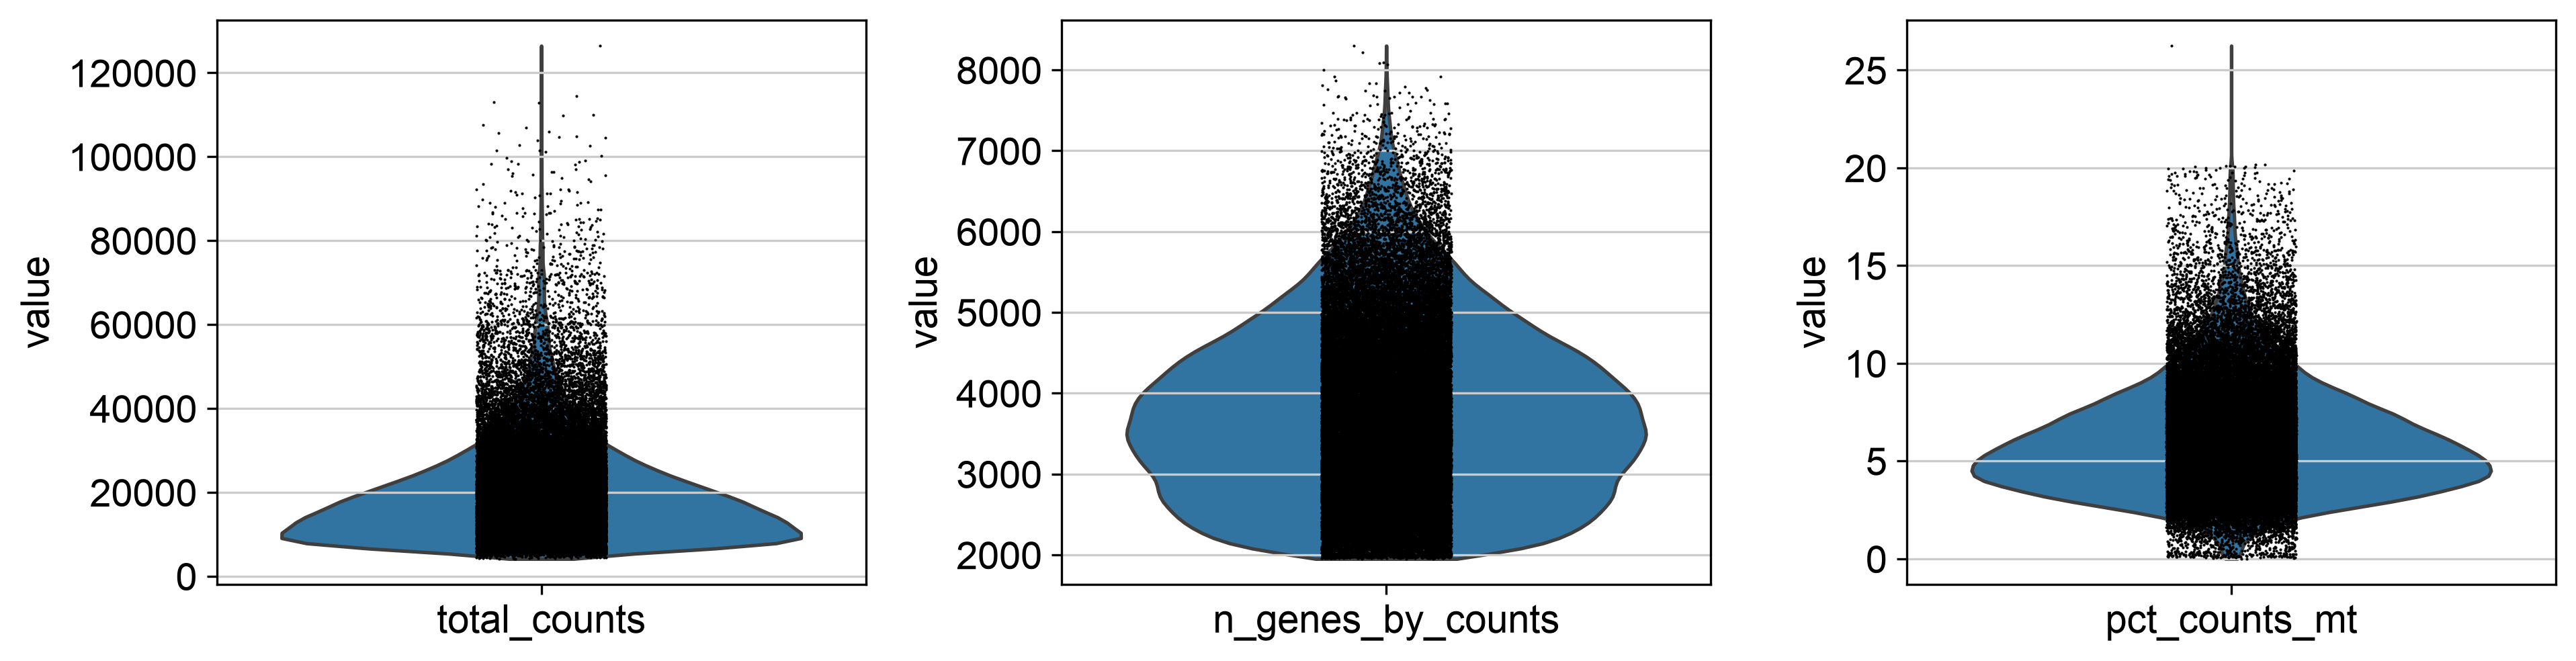

In [2]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=True, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sc.pl.violin(adata, 'total_counts', ax=axes[0], show=False)
sc.pl.violin(adata, 'n_genes_by_counts', ax=axes[1], show=False)
sc.pl.violin(adata, 'pct_counts_mt', ax=axes[2], show=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '02_qc_violins.pdf'))

In [3]:
adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()

,total_counts,n_genes_by_counts,pct_counts_mt
count,53513.000000,53513.000000,53513.000000
mean,19684.819614,3757.289257,6.093586
std,12043.727292,1076.852243,2.831299
min,4144.000000,1951.000000,0.000000
25%,11039.000000,2909.000000,4.085133
50%,16733.000000,3661.000000,5.607406
75%,24750.000000,4461.000000,7.596342
max,126430.000000,8299.000000,26.246585


## Normalization and clustering

Standard scanpy pipeline: library-size normalization to 10,000 counts/cell, log1p, highly variable genes, PCA, neighbors graph, Leiden clustering, UMAP. The raw UMI counts are kept in a `counts` layer so notebook 03 can choose the appropriate representation for marker-gene comparisons (see the normalization note there).

In [4]:
def basic_scanpy_preprocessing(adata, n_top_genes=2000, n_neighbors=10, n_pcs=40, random_state=20):
    adata.layers['counts'] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor='seurat')
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=random_state)
    sc.tl.umap(adata, random_state=random_state)
    sc.tl.leiden(adata, random_state=random_state)
    return adata

adata = basic_scanpy_preprocessing(adata)
adata

/Users/rishika/Projects/scRNA-onco-analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_53399/3099417808.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, random_state=random_state)


AnnData object with n_obs × n_vars = 53513 × 23081
    obs: 'CellLine', 'Pool', 'Indication', 'Genes_expressed', 'Discrete_cluster_minpts5_eps1.8', 'Discrete_cluster_minpts5_eps1.5', 'Discrete_cluster_minpts5_eps1.2', 'CNA_subclone', 'SkinPig_score', 'EMTI_score', 'EMTII_score', 'EMTIII_score', 'IFNResp_score', 'p53Sen_score', 'EpiSen_score', 'StressResp_score', 'ProtMatu_score', 'ProtDegra_score', 'G1_S_score', 'G2_M_score', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## Figure 1-style embedding

Two colorings of the same UMAP: by `Indication` (cancer type) and by `CellLine`. Kinker et al.'s point is that the second one shows tight, well-separated clusters — cells group by which cell line they came from, not by cancer type — while the first looks comparatively mixed, since most cancer types here are represented by several transcriptionally distinct cell lines.

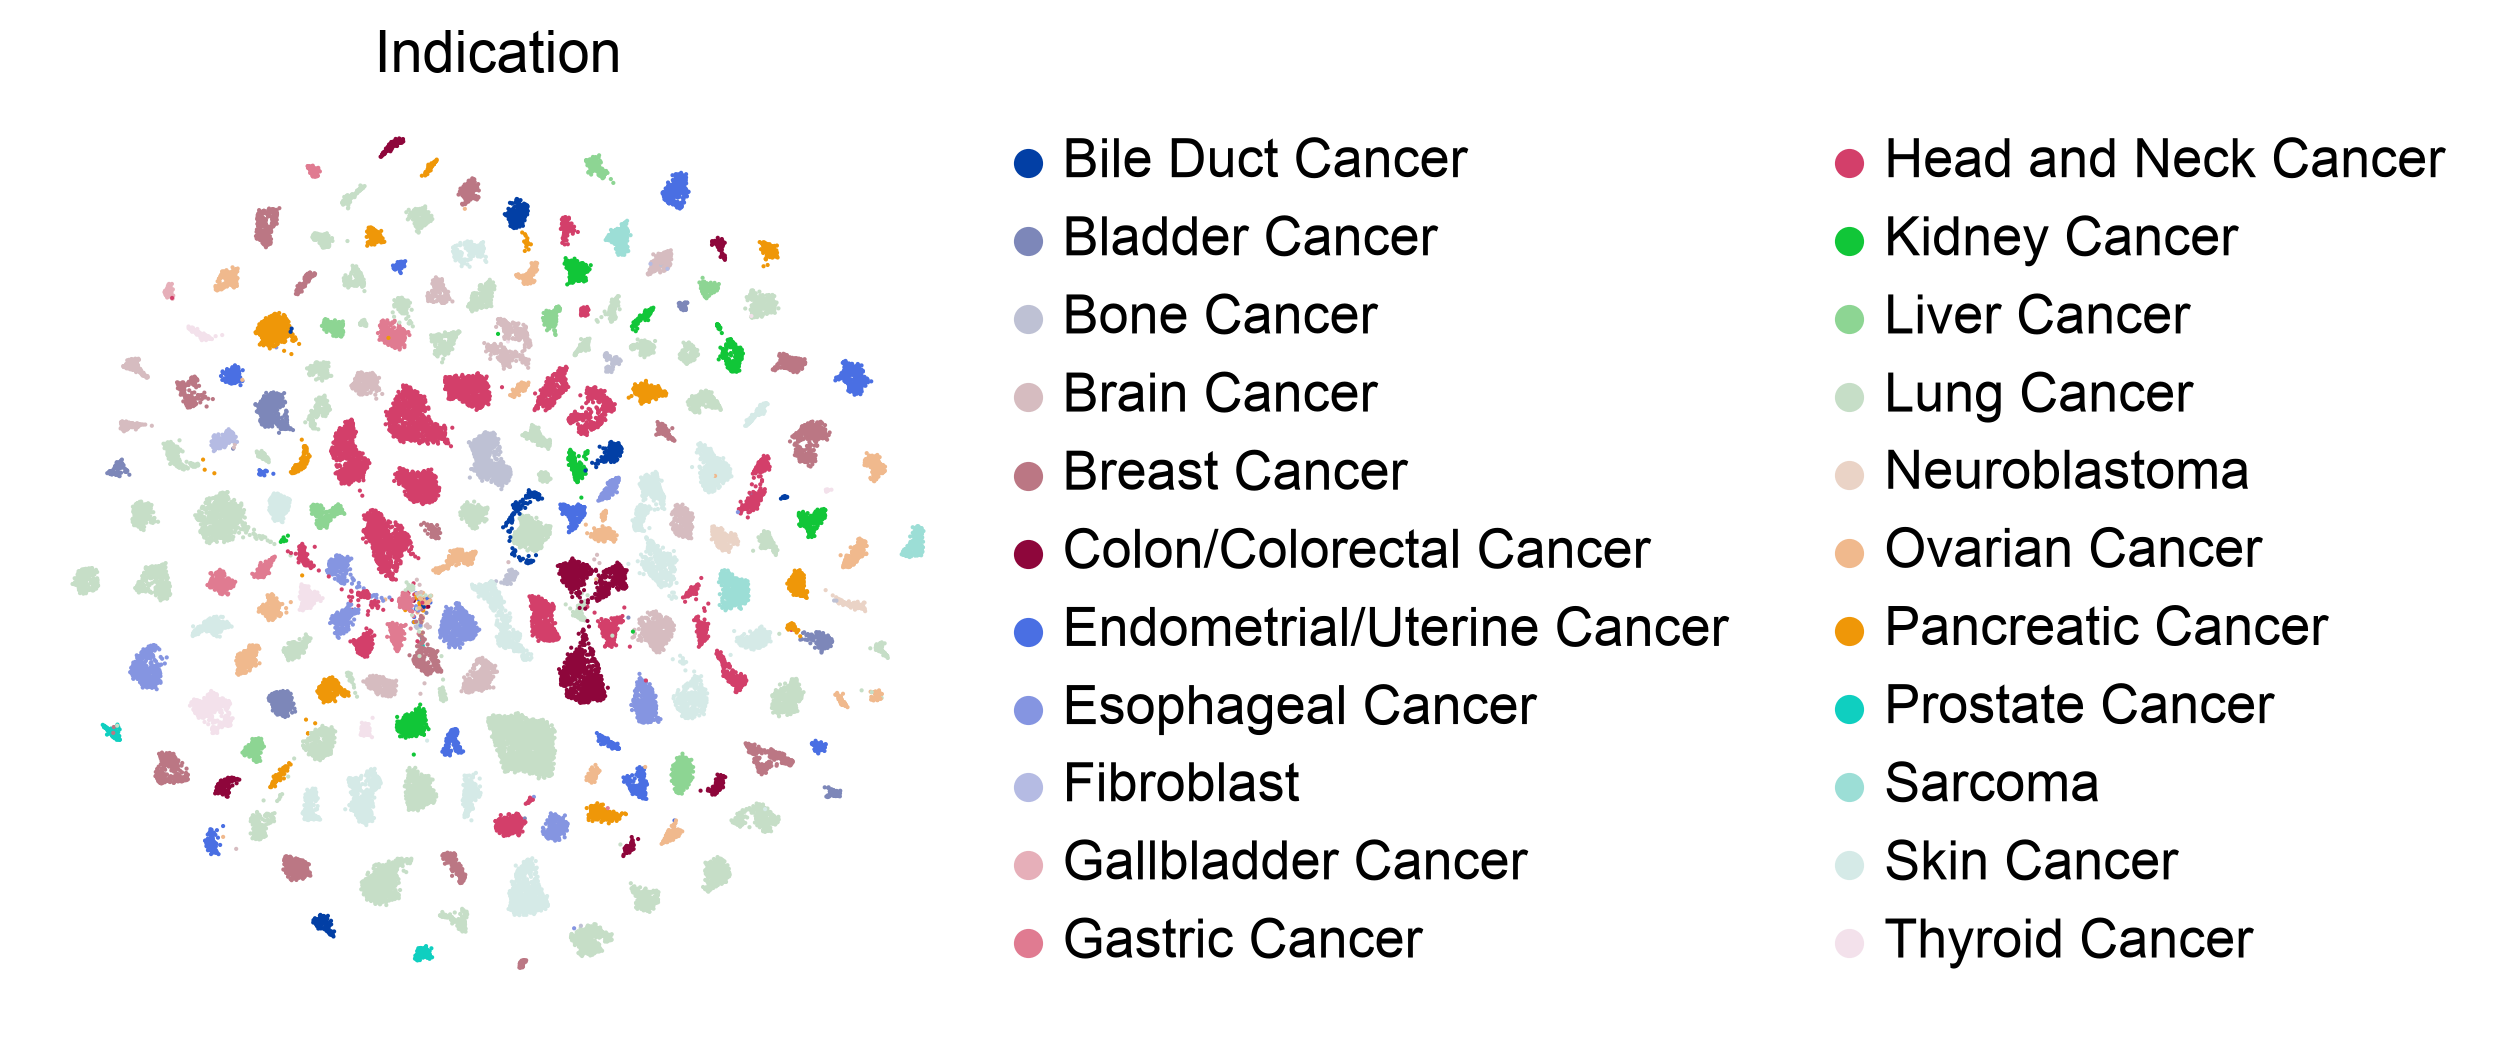

In [5]:
fig = sc.pl.umap(adata, color='Indication', size=4, show=False, return_fig=True)
fig.savefig(os.path.join(FIG_DIR, '02_umap_by_indication.pdf'), bbox_inches='tight')
plt.show()

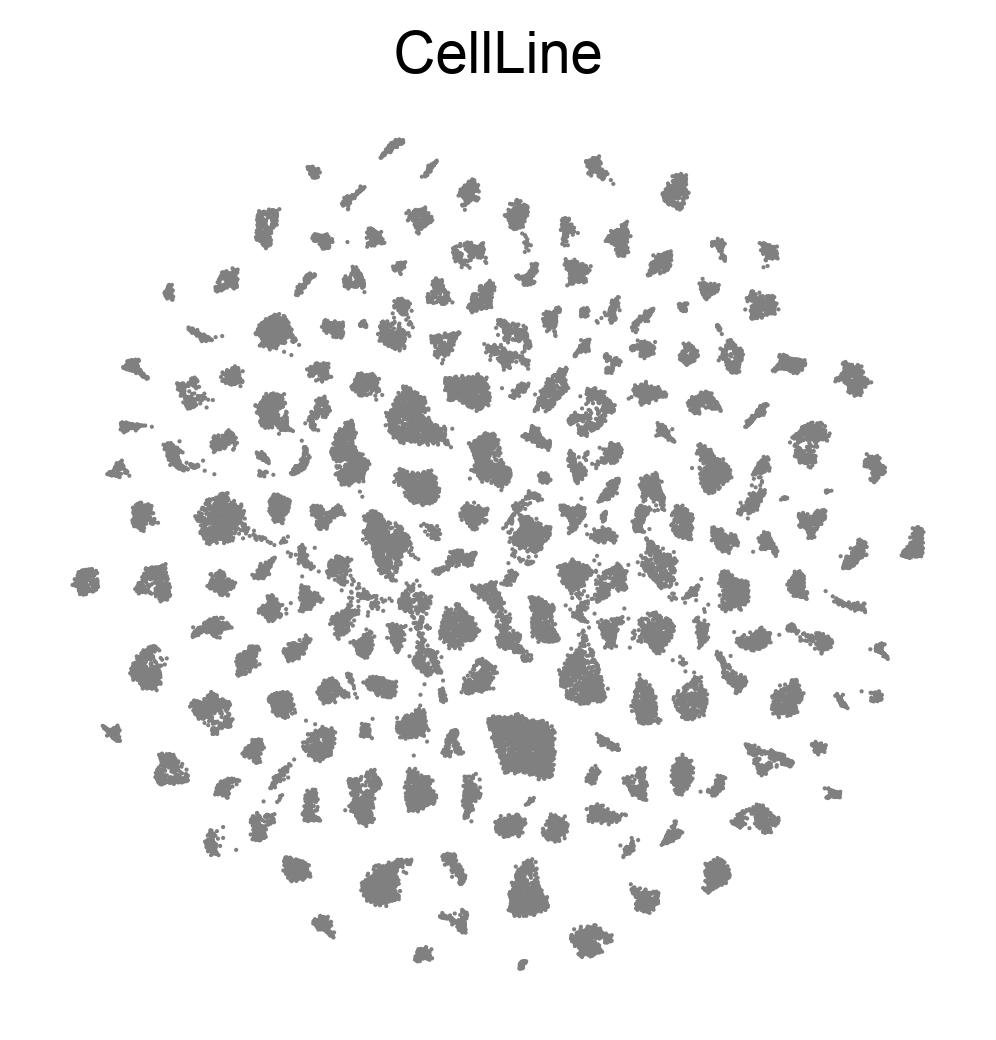

In [6]:
# CellLine has ~190+ categories - too many for a legend, so we drop it and rely on visual cluster separation
fig = sc.pl.umap(adata, color='CellLine', size=4, show=False, return_fig=True, legend_loc=None)
fig.savefig(os.path.join(FIG_DIR, '02_umap_by_cellline.pdf'), bbox_inches='tight')
plt.show()

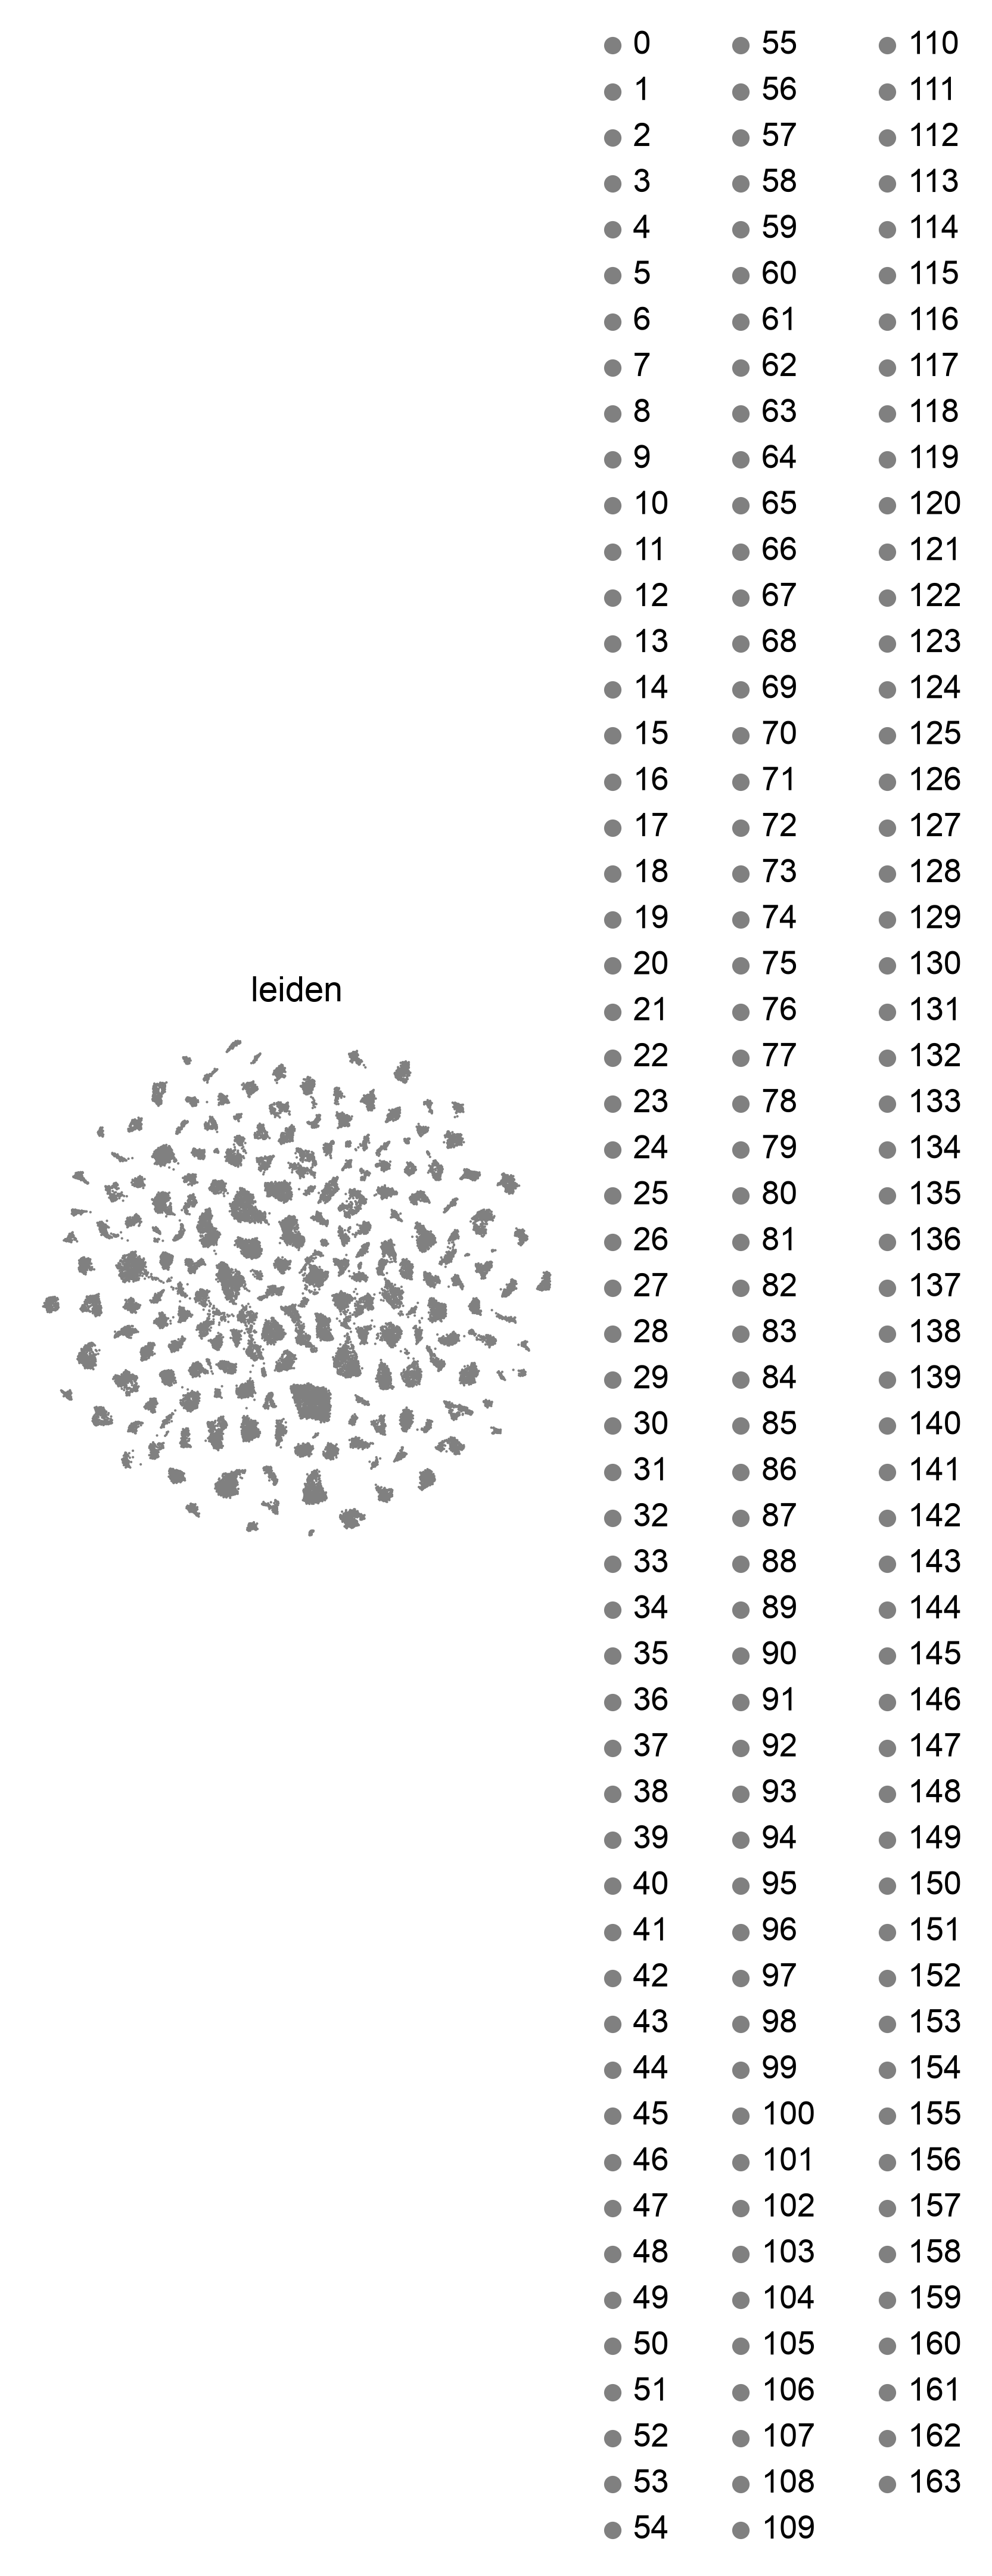

In [7]:
fig = sc.pl.umap(adata, color='leiden', size=4, show=False, return_fig=True)
fig.savefig(os.path.join(FIG_DIR, '02_umap_by_leiden.pdf'), bbox_inches='tight')
plt.show()

## How well does clustering recover cell line identity?

A simple sanity check: for each Leiden cluster, what fraction of its cells come from the single most common cell line in that cluster? Values close to 1 across most clusters would support the paper's claim that cell-line identity is the dominant axis of variation.

In [8]:
purity = (
    adata.obs.groupby('leiden')['CellLine']
    .agg(lambda s: s.value_counts(normalize=True).iloc[0])
    .rename('top_cellline_fraction')
)
purity.describe()

/var/folders/hn/zw0sbvr9603b7m_bzxhsm9080000gn/T/ipykernel_53399/2145743798.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('leiden')['CellLine']


count    164.000000
mean       0.928437
std        0.157405
min        0.347097
25%        0.989198
50%        0.999498
75%        1.000000
max        1.000000
Name: top_cellline_fraction, dtype: float64

In [9]:
adata.write(os.path.join(OUTS_DIR, '02_qc_clustering.h5ad'))